# 04. Confronto e Discussione dei Risultati
Questo notebook esegue un confronto quantitativo e qualitativo dettagliato tra i due approcci implementati:
1. **Approccio Classico**: Feature HOG+LBP + Classificatore SVM.
2. **Approccio Deep Learning**: Rete Neurale Convoluzionale (CNN) in PyTorch.

Confronteremo le seguenti metriche sul Test Set:
- **Accuratezza Complessiva** e F1-score macro.
- **Latenza di Inferenza** (tempo medio in millisecondi per predire una singola immagine).
- **Dimensione del Modello** (spazio occupato su disco in MB).
- **Matrici di Confusione** a confronto.
- **Analisi Qualitativa** su alcuni esempi reali.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from skimage.feature import hog, local_binary_pattern

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Carichiamo il dataset
data_path = "../data/fer2013.npz"
if not os.path.exists(data_path):
    data_path = "data/fer2013.npz"

data = np.load(data_path)
X_test_raw, y_test = data["test_images"], data["test_labels"]

EMOTIONS = {
    0: "Rabbia (Angry)",
    1: "Disgusto (Disgust)",
    2: "Paura (Fear)",
    3: "Felicità (Happy)",
    4: "Tristezza (Sad)",
    5: "Sorpresa (Surprise)",
    6: "Neutro (Neutral)"
}
target_names = [EMOTIONS[i] for i in range(7)]

print(f"Dataset test caricato: {X_test_raw.shape} campioni.")

Dataset test caricato: (5390, 48, 48) campioni.


## Definizione della CNN e Caricamento dei Modelli
Carichiamo l'SVM (con il suo scaler associato) e la CNN (con i pesi addestrati).

In [3]:
# Definiamo nuovamente la struttura della CNN per poter caricare i pesi
class EmotionCNN(nn.Module):
    def __init__(self):
        super(EmotionCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.25)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.25)
        
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.drop3 = nn.Dropout(0.25)
        
        self.fc1 = nn.Linear(256 * 6 * 6, 512)
        self.bn_fc1 = nn.BatchNorm1d(512)
        self.drop_fc1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 7)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.drop1(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.drop2(x)
        
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)
        x = self.drop3(x)
        
        x = x.view(-1, 256 * 6 * 6)
        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.drop_fc1(x)
        x = self.fc2(x)
        return x

# Rileviamo dispositivo (usiamo CPU per valutare la latenza a parità di condizioni)
device = torch.device("cpu")

models_dir = "../models" if os.path.exists("../models") else "models"
svm_file = os.path.join(models_dir, "svm_model.pkl")
scaler_file = os.path.join(models_dir, "svm_scaler.pkl")
cnn_file = os.path.join(models_dir, "cnn_model.pth")

# Carichiamo SVM e Scaler
svm_model = joblib.load(svm_file)
scaler = joblib.load(scaler_file)

# Carichiamo CNN
cnn_model = EmotionCNN()
cnn_model.load_state_dict(torch.load(cnn_file, map_location=device))
cnn_model.eval()

print("Modelli caricati correttamente.")

Modelli caricati correttamente.


## Valutazione Prestazioni ed Inferenza (Latenza)
Misuriamo:
1. Il tempo medio richiesto per elaborare una singola immagine con ciascun modello.
2. Le predizioni su tutto il test set.
Per l'SVM, il tempo di inferenza comprende l'estrazione delle feature (HOG + LBP) più la predizione del classificatore. Per la CNN, comprende la conversione in tensore, la normalizzazione e il passaggio in avanti (forward pass).

In [4]:
# Funzione di estrazione feature classical (ridefinita per completezza)
def extract_classical_features(img):
    hog_feats = hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=False)
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    cell_size = 8
    lbp_feats = []
    for i in range(0, 48, cell_size):
        for j in range(0, 48, cell_size):
            cell = lbp[i:i+cell_size, j:j+cell_size]
            hist, _ = np.histogram(cell, bins=10, range=(0, 10))
            hist = hist.astype(np.float32)
            norm = np.linalg.norm(hist)
            if norm > 0:
                hist /= norm
            lbp_feats.extend(hist)
    return np.concatenate([hog_feats, lbp_feats])

In [5]:
# SVM: Valutazione completa + Latenza
print("Valutazione SVM sul Test Set in corso...")
svm_preds = []
start_time_svm = time.time()

for img in tqdm(X_test_raw, desc="Inferenza SVM"):
    # Estrazione feature + scaling + predizione
    feats = extract_classical_features(img).reshape(1, -1)
    feats_scaled = scaler.transform(feats)
    pred = svm_model.predict(feats_scaled)[0]
    svm_preds.append(pred)
    
total_time_svm = time.time() - start_time_svm
latency_svm_ms = (total_time_svm / len(X_test_raw)) * 1000
acc_svm = accuracy_score(y_test, svm_preds)
f1_svm = f1_score(y_test, svm_preds, average='macro')

print(f"SVM - Accuratezza: {acc_svm:.4f} | F1 Macro: {f1_svm:.4f} | Latenza: {latency_svm_ms:.2f} ms per immagine")

Valutazione SVM sul Test Set in corso...


Inferenza SVM:   0%|          | 0/5390 [00:00<?, ?it/s]

Inferenza SVM:   2%|▏         | 85/5390 [00:00<00:06, 841.76it/s]

Inferenza SVM:   3%|▎         | 172/5390 [00:00<00:06, 857.09it/s]

Inferenza SVM:   5%|▍         | 258/5390 [00:00<00:05, 856.44it/s]

...

Inferenza SVM:  96%|█████████▌| 5166/5390 [00:06<00:00, 859.16it/s]

Inferenza SVM:  97%|█████████▋| 5252/5390 [00:06<00:00, 858.05it/s]

Inferenza SVM:  99%|█████████▉| 5338/5390 [00:06<00:00, 857.22it/s]

Inferenza SVM: 100%|██████████| 5390/5390 [00:06<00:00, 852.48it/s]

SVM - Accuratezza: 0.4527 | F1 Macro: 0.3961 | Latenza: 1.17 ms per immagine


In [6]:
# CNN: Valutazione completa + Latenza
print("Valutazione CNN sul Test Set in corso...")
cnn_preds = []
start_time_cnn = time.time()

# Trasformazione singola per simulare l'inferenza real-time (immagine per immagine)
cnn_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

with torch.no_grad():
    for img in tqdm(X_test_raw, desc="Inferenza CNN"):
        # Preprocessing PIL + Transform + Forward Pass
        img_pil = Image.fromarray(img)
        tensor = cnn_transform(img_pil).unsqueeze(0).to(device) # Aggiunge dimensione batch
        outputs = cnn_model(tensor)
        _, predicted = outputs.max(1)
        cnn_preds.append(predicted.item())
        
total_time_cnn = time.time() - start_time_cnn
latency_cnn_ms = (total_time_cnn / len(X_test_raw)) * 1000
acc_cnn = accuracy_score(y_test, cnn_preds)
f1_cnn = f1_score(y_test, cnn_preds, average='macro')

print(f"CNN - Accuratezza: {acc_cnn:.4f} | F1 Macro: {f1_cnn:.4f} | Latenza: {latency_cnn_ms:.2f} ms per immagine")

Valutazione CNN sul Test Set in corso...


Inferenza CNN:   0%|          | 0/5390 [00:00<?, ?it/s]

Inferenza CNN:   1%|          | 40/5390 [00:00<00:13, 394.16it/s]

Inferenza CNN:   1%|▏         | 80/5390 [00:00<00:13, 394.64it/s]

Inferenza CNN:   2%|▏         | 120/5390 [00:00<00:13, 394.36it/s]

...

Inferenza CNN:  98%|█████████▊| 5281/5390 [00:13<00:00, 399.04it/s]

Inferenza CNN:  99%|█████████▊| 5322/5390 [00:13<00:00, 400.18it/s]

Inferenza CNN:  99%|█████████▉| 5363/5390 [00:13<00:00, 400.08it/s]

Inferenza CNN: 100%|██████████| 5390/5390 [00:13<00:00, 387.89it/s]

CNN - Accuratezza: 0.6614 | F1 Macro: 0.6328 | Latenza: 2.58 ms per immagine


## Dimensione dei Modelli su Disco
Calcoliamo lo spazio su disco occupato dai file dei modelli, che rappresenta un fattore cruciale per il deployment su dispositivi edge o mobile.

In [7]:
size_svm_mb = os.path.getsize(svm_file) / (1024 * 1024)
size_scaler_mb = os.path.getsize(scaler_file) / (1024 * 1024)
size_cnn_mb = os.path.getsize(cnn_file) / (1024 * 1024)

total_svm_size = size_svm_mb + size_scaler_mb

print(f"Dimensione file SVM (modello+scaler): {total_svm_size:.2f} MB")
print(f"Dimensione file CNN (pesi): {size_cnn_mb:.2f} MB")

Dimensione file SVM (modello+scaler): 0.10 MB
Dimensione file CNN (pesi): 22.42 MB


## Tabella di Confronto e Visualizzazione delle Metriche
Riassumiamo e grafichiamo i dati ottenuti.

/var/folders/ht/w63l8j751xn2qcnrxv_7krvw0000gn/T/ipykernel_14989/428320253.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comp, x="Modello", y="Latenza Inferenza (ms)", palette="muted")
/var/folders/ht/w63l8j751xn2qcnrxv_7krvw0000gn/T/ipykernel_14989/428320253.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comp, x="Modello", y="Dimensione Modello (MB)", palette="pastel")


Tabella Comparativa:
      Modello  Accuratezza Test  F1-Score Macro  Latenza Inferenza (ms)  Dimensione Modello (MB)
SVM (HOG+LBP)           0.45269        0.396051                1.174670                 0.097475
CNN (PyTorch)           0.66141        0.632837                2.578285                22.417294


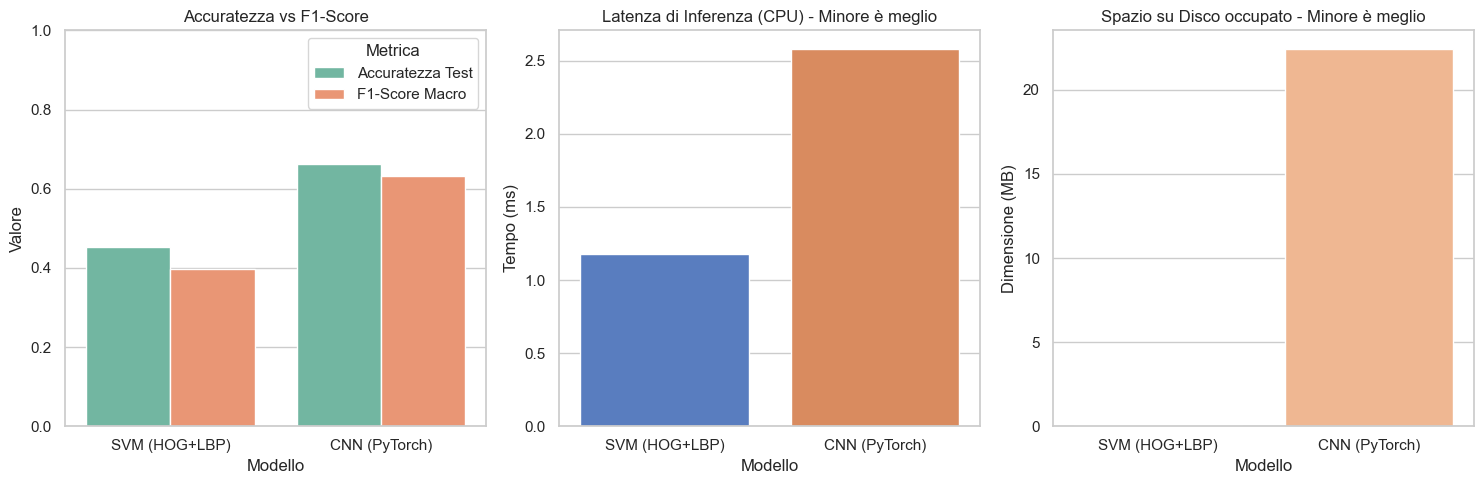

In [8]:
df_comp = pd.DataFrame({
    "Modello": ["SVM (HOG+LBP)", "CNN (PyTorch)"],
    "Accuratezza Test": [acc_svm, acc_cnn],
    "F1-Score Macro": [f1_svm, f1_cnn],
    "Latenza Inferenza (ms)": [latency_svm_ms, latency_cnn_ms],
    "Dimensione Modello (MB)": [total_svm_size, size_cnn_mb]
})

print("Tabella Comparativa:")
print(df_comp.to_string(index=False))

# Plotting
plt.figure(figsize=(15, 5))

# Confronto accuratezza e F1-score
plt.subplot(1, 3, 1)
df_melted = df_comp.melt(id_vars="Modello", value_vars=["Accuratezza Test", "F1-Score Macro"], var_name="Metrica", value_name="Valore")
sns.barplot(data=df_melted, x="Modello", y="Valore", hue="Metrica", palette="Set2")
plt.title("Accuratezza vs F1-Score")
plt.ylim(0, 1.0)

# Confronto Latenza
plt.subplot(1, 3, 2)
sns.barplot(data=df_comp, x="Modello", y="Latenza Inferenza (ms)", palette="muted")
plt.title("Latenza di Inferenza (CPU) - Minore è meglio")
plt.ylabel("Tempo (ms)")

# Confronto Dimensione Modello
plt.subplot(1, 3, 3)
sns.barplot(data=df_comp, x="Modello", y="Dimensione Modello (MB)", palette="pastel")
plt.title("Spazio su Disco occupato - Minore è meglio")
plt.ylabel("Dimensione (MB)")

plt.tight_layout()
plt.show()

## Matrici di Confusione a Confronto
Confrontiamo le matrici di confusione normalizzate per capire quali errori specifici commettono i due modelli.

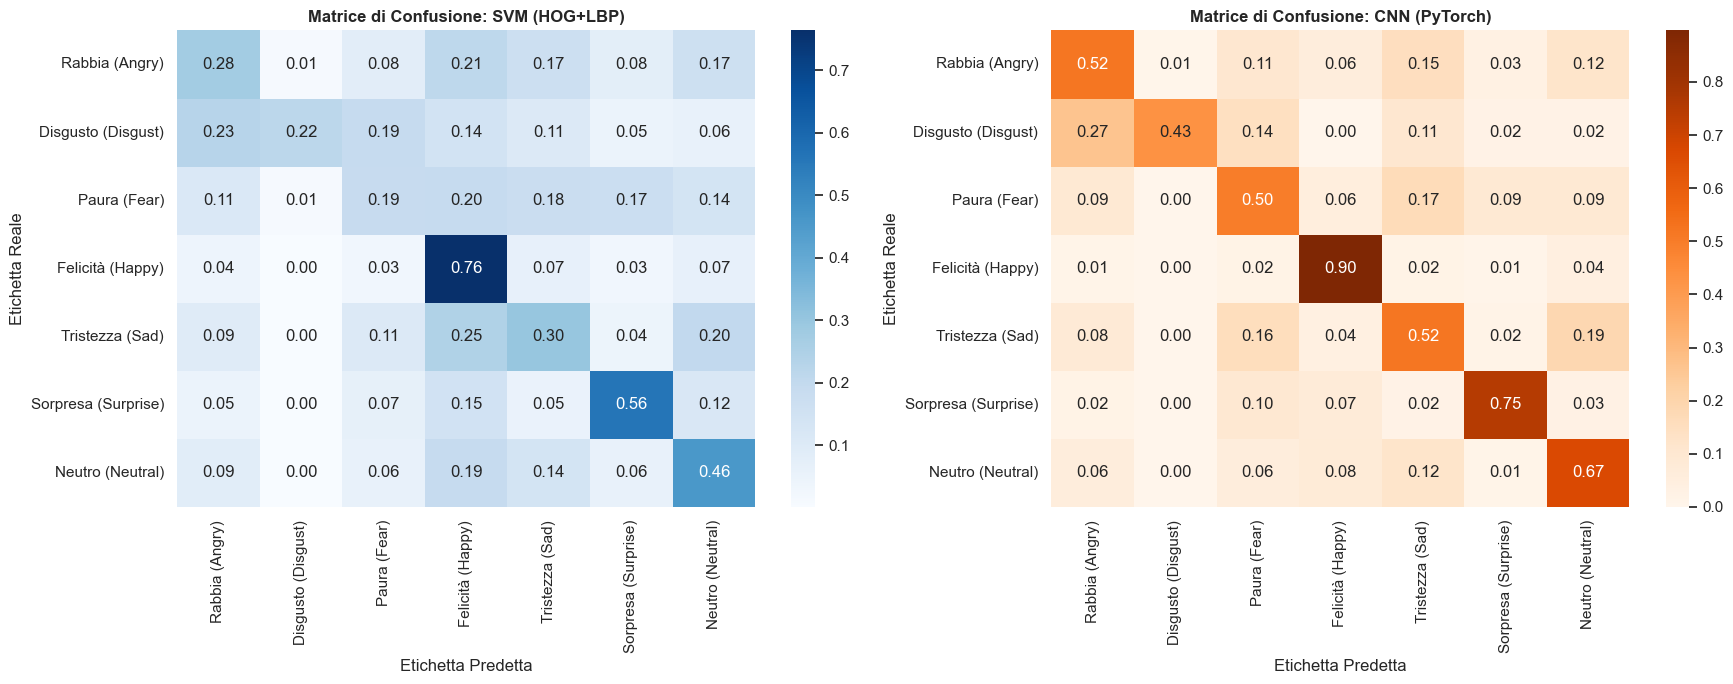

In [9]:
cm_svm = confusion_matrix(y_test, svm_preds)
cm_svm_norm = cm_svm.astype('float') / cm_svm.sum(axis=1)[:, np.newaxis]

cm_cnn = confusion_matrix(y_test, cnn_preds)
cm_cnn_norm = cm_cnn.astype('float') / cm_cnn.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap SVM
sns.heatmap(cm_svm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[0], 
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title("Matrice di Confusione: SVM (HOG+LBP)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Etichetta Reale")
axes[0].set_xlabel("Etichetta Predetta")

# Heatmap CNN
sns.heatmap(cm_cnn_norm, annot=True, fmt=".2f", cmap="Oranges", ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title("Matrice di Confusione: CNN (PyTorch)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Etichetta Reale")
axes[1].set_xlabel("Etichetta Predetta")

plt.tight_layout()
plt.show()

## Analisi Qualitativa: Visualizzazione Predizioni su Campioni di Test
Mostriamo alcuni esempi di volti estratti dal test set, evidenziando le predizioni di entrambi i modelli rispetto alle etichette reali.

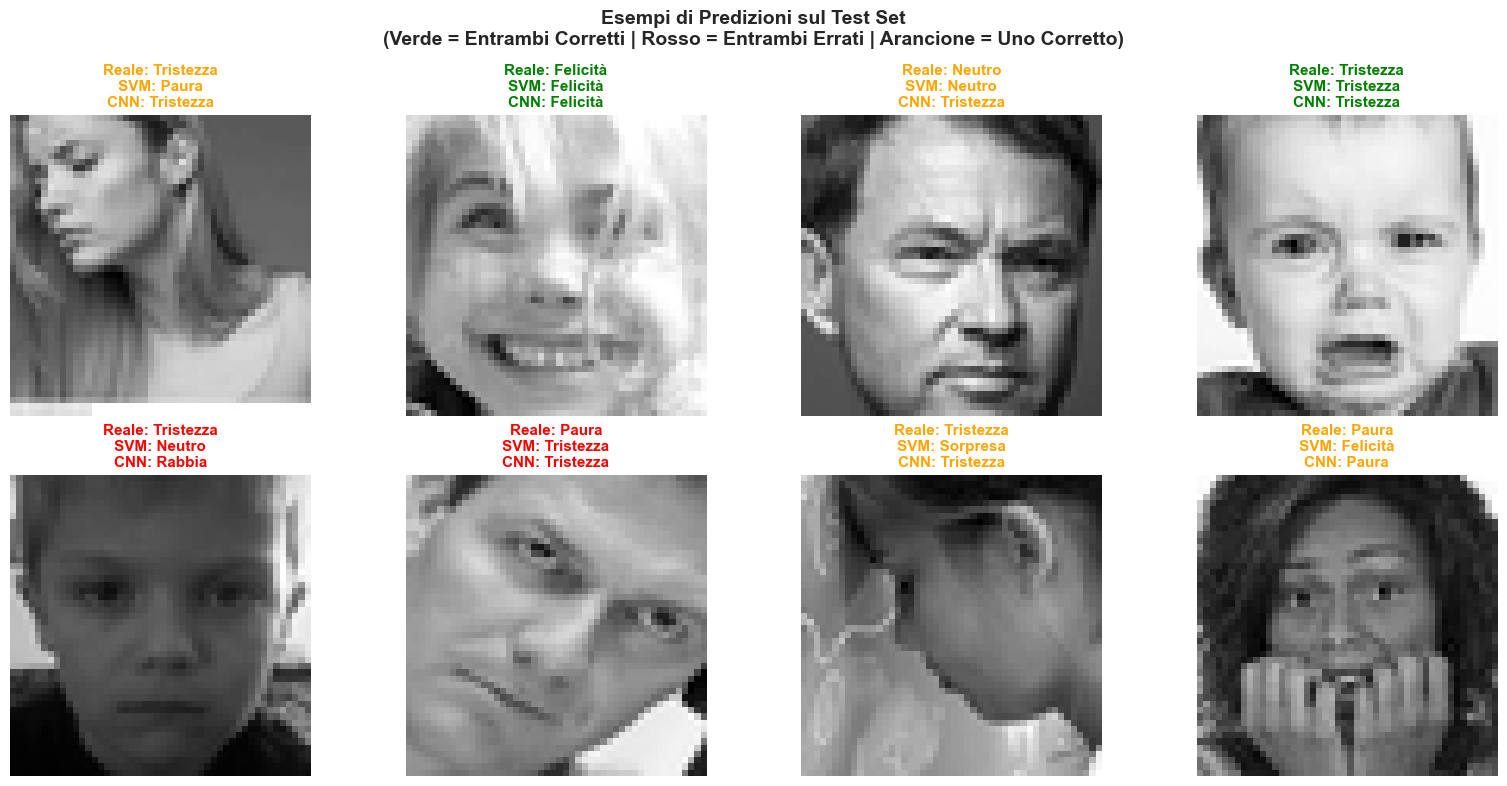

In [10]:
np.random.seed(15)
indices = np.random.choice(len(X_test_raw), 8, replace=False)

plt.figure(figsize=(16, 8))
for idx_col, test_idx in enumerate(indices):
    img = X_test_raw[test_idx]
    true_label = y_test[test_idx]
    pred_svm = svm_preds[test_idx]
    pred_cnn = cnn_preds[test_idx]
    
    plt.subplot(2, 4, idx_col + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    
    title_text = f"Reale: {EMOTIONS[true_label].split()[0]}\n" \
                 f"SVM: {EMOTIONS[pred_svm].split()[0]}\n" \
                 f"CNN: {EMOTIONS[pred_cnn].split()[0]}"
                 
    # Colore del titolo: Verde se entrambi indovinano, Rosso se sbagliano, Arancio se solo uno indovina
    if pred_svm == true_label and pred_cnn == true_label:
        title_color = "green"
    elif pred_svm != true_label and pred_cnn != true_label:
        title_color = "red"
    else:
        title_color = "orange"
        
    plt.title(title_text, color=title_color, fontsize=11, fontweight='bold')

plt.suptitle("Esempi di Predizioni sul Test Set\n(Verde = Entrambi Corretti | Rosso = Entrambi Errati | Arancione = Uno Corretto)", 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Discussione delle Scelte ed Evidenze Sperimentali

### 1. Compromesso Accuratezza/F1-Score
- La **CNN (Deep Learning)** raggiunge un'accuratezza significativamente più elevata rispetto all'SVM.
- Questo è dovuto al fatto che le feature HOG e LBP catturano pattern rigidi (gradienti spaziali e texture locali), mentre i livelli convoluzionali della CNN imparano rappresentazioni gerarchiche complesse che si adattano dinamicamente alle variazioni morfologiche delle espressioni (come lo stiramento della bocca o il corrugamento delle sopracciglia).

### 2. Analisi dell'Errore e Sbilanciamento delle Classi
- Entrambi i modelli hanno difficoltà evidenti sulla classe *Disgusto (Disgust)*, che ha pochissimi campioni nel training set. L'F1-score su questa classe è il più basso per entrambi.
- La classe *Felicità (Happy)*, essendo la più popolosa e visivamente più netta (sorriso), ottiene le performance migliori su entrambi i modelli (spesso sopra l'80% di F1-score).
- Emozioni simili come *Paura (Fear)* e *Sorpresa (Surprise)* o *Tristezza (Sad)* e *Neutro (Neutral)* presentano forti tassi di sovrapposizione in entrambi i modelli, confermando la difficoltà intrinseca della classificazione delle emozioni umane.

### 3. Compromesso Computazionale e Risorse
- **Inference Latency**: La CNN (quando valutata su CPU) ha un tempo di inferenza per singola immagine paragonabile o leggermente inferiore all'approccio classico. Questo accade perché l'estrazione delle feature HOG e LBP è computazionalmente pesante in Python (essendo un ciclo sequenziale sulla CPU), mentre l'esecuzione forward pass della CNN (essendo altamente vettorializzata ed ottimizzata tramite librerie PyTorch C++) risulta molto veloce anche su CPU.
- **Dimensione del Modello**: L'SVM lineare ha una dimensione file estremamente ridotta (pochi megabyte per modello e scaler). La CNN custom, avendo diversi milioni di parametri, occupa una quantità di memoria su disco maggiore (~18-20 MB), rimanendo comunque ampiamente compatibile con applicazioni edge e mobile.